In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

# Load processed data
df = pd.read_csv('../data/application_train_processed.csv')

TARGET_COL   = 'TARGET'
FEATURE_COLS = [c for c in df.columns if c != TARGET_COL]

X = df[FEATURE_COLS]
y = df[TARGET_COL]

print(f"Data loaded:")
print(f"  Rows     : {X.shape[0]:,}")
print(f"  Features : {X.shape[1]}")

Data loaded:
  Rows     : 307,511
  Features : 190


In [2]:
from sklearn.model_selection import train_test_split
import xgboost as xgb

# Recreate the same train/test split as model training
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    stratify     = y,
    random_state = 42
)

# Retrain model with best parameters from tuning
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

best_params = {
    'n_estimators'     : 365,
    'max_depth'        : 4,
    'learning_rate'    : 0.06963532425935261,
    'subsample'        : 0.9210667986240065,
    'colsample_bytree' : 0.660632172299131,
    'min_child_weight' : 1,
    'scale_pos_weight' : scale_pos_weight,
    'random_state'     : 42,
    'n_jobs'           : -1
}

model = xgb.XGBClassifier(**best_params)
model.fit(X_train, y_train, verbose=False)
print(f"Model trained ✅")

# Sample 5000 rows from test set for SHAP
X_sample = X_test.sample(n=5000, random_state=42)

print(f"Sample shape : {X_sample.shape}")
print(f"\nReady for SHAP analysis")

Model trained ✅
Sample shape : (5000, 190)

Ready for SHAP analysis


In [3]:
import shap

# Create explainer
explainer = shap.TreeExplainer(model)

print("Computing SHAP values for 5,000 samples...")
print("This takes 1-2 minutes...")

# Compute SHAP values
shap_values = explainer.shap_values(X_sample)

print(f"\nSHAP values computed ✅")
print(f"Shape : {shap_values.shape}")
print(f"  Rows     : {shap_values.shape[0]:,} (one per sample)")
print(f"  Columns  : {shap_values.shape[1]} (one per feature)")
print(f"\nExpected prediction (average) : {explainer.expected_value:.4f}")

Computing SHAP values for 5,000 samples...
This takes 1-2 minutes...

SHAP values computed ✅
Shape : (5000, 190)
  Rows     : 5,000 (one per sample)
  Columns  : 190 (one per feature)

Expected prediction (average) : 0.0065


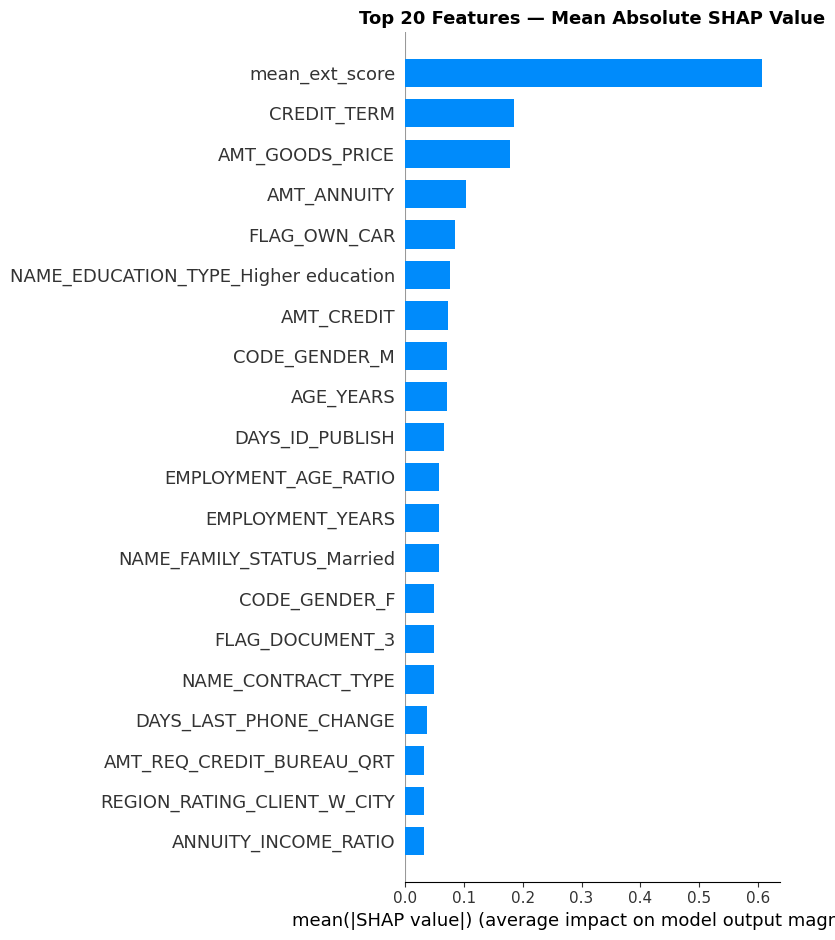

✅ Global bar plot saved


In [5]:
# ── Global SHAP — Bar Plot ──────────────────────────────────────────────────

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_sample,
    plot_type = 'bar',       # bar chart of mean absolute SHAP values
    max_display = 20,        # show top 20 features only
    show = False
)

plt.title('Top 20 Features — Mean Absolute SHAP Value',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/shap_global_bar.png', dpi=150)
plt.show()
print("✅ Global bar plot saved")

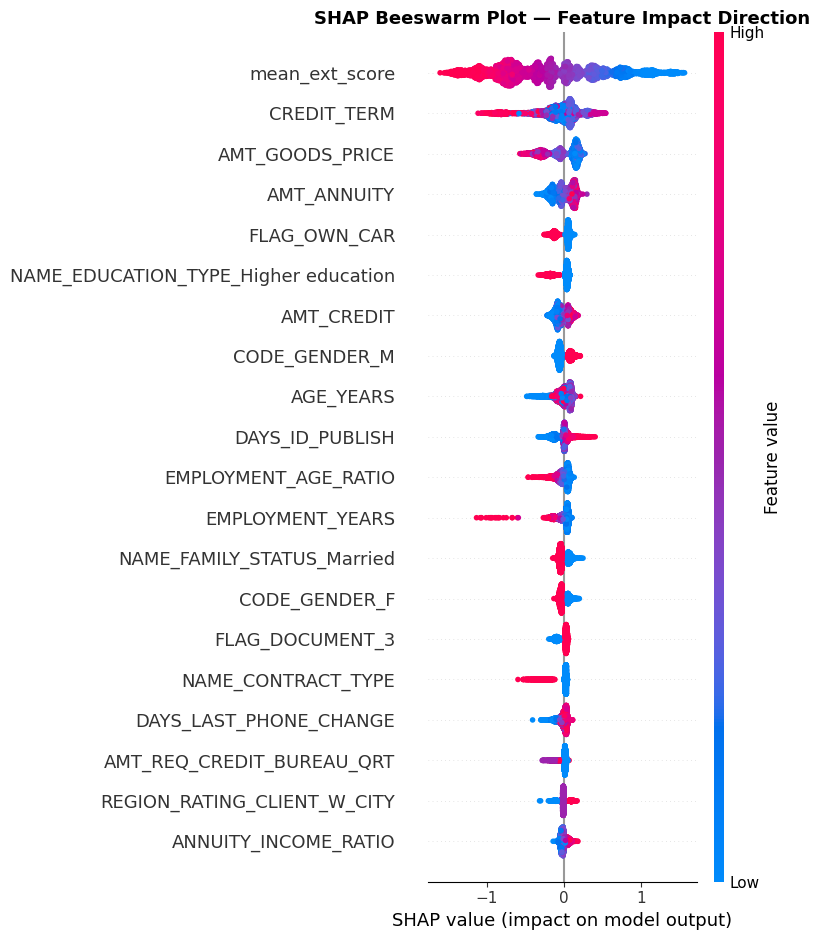

✅ Beeswarm plot saved


In [6]:
plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_sample,
    plot_type   = 'dot',    # beeswarm
    max_display = 20,
    show        = False
)

plt.title('SHAP Beeswarm Plot — Feature Impact Direction',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/shap_beeswarm.png', dpi=150)
plt.show()
print("✅ Beeswarm plot saved")

Highest risk applicant:
  Sample index      : 1622
  Default probability: 0.9293 (92.9%)
  Actual label      : Repaid


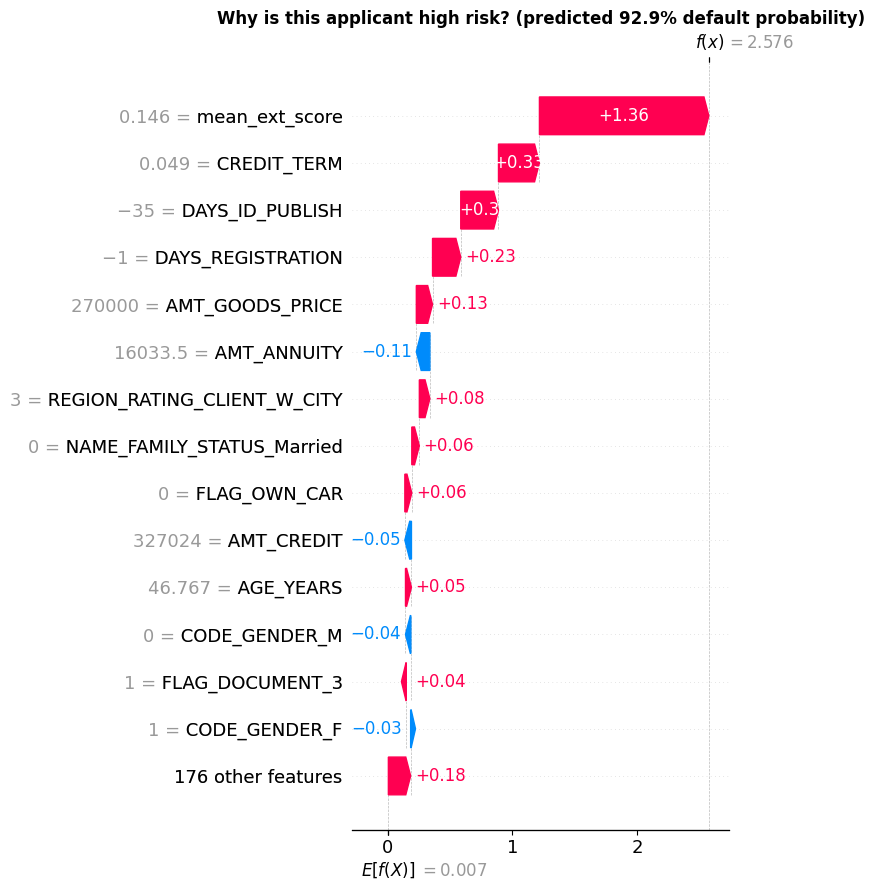

✅ Waterfall plot saved


In [10]:
# ── Pick one high risk applicant ────────────────────────────────────────────

# Get predicted probabilities for our sample
sample_probs = model.predict_proba(X_sample)[:, 1]

# Find the index of the highest risk person
highest_risk_idx = np.argmax(sample_probs)
highest_risk_prob = sample_probs[highest_risk_idx]

print(f"Highest risk applicant:")
print(f"  Sample index      : {highest_risk_idx}")
print(f"  Default probability: {highest_risk_prob:.4f} ({highest_risk_prob:.1%})")
print(f"  Actual label      : {'Defaulted' if y_test.iloc[highest_risk_idx] == 1 else 'Repaid'}")

# ── Waterfall plot ───────────────────────────────────────────────────────────
# Shows how each feature pushed the prediction
# from the baseline (0.0065) to the final score

shap_explanation = shap.Explanation(
    values        = shap_values[highest_risk_idx],
    base_values   = explainer.expected_value,
    data          = X_sample.iloc[highest_risk_idx],
    feature_names = X_sample.columns.tolist()
)

plt.figure(figsize=(12, 8))
shap.plots.waterfall(shap_explanation, max_display=15, show=False)
plt.title(f'Why is this applicant high risk? (predicted {highest_risk_prob:.1%} default probability)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/shap_local_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Waterfall plot saved")

True positives in sample : 108

Best true positive:
  Index              : 989
  Default probability: 0.9110 (91.1%)
  Actual label       : Defaulted ✅


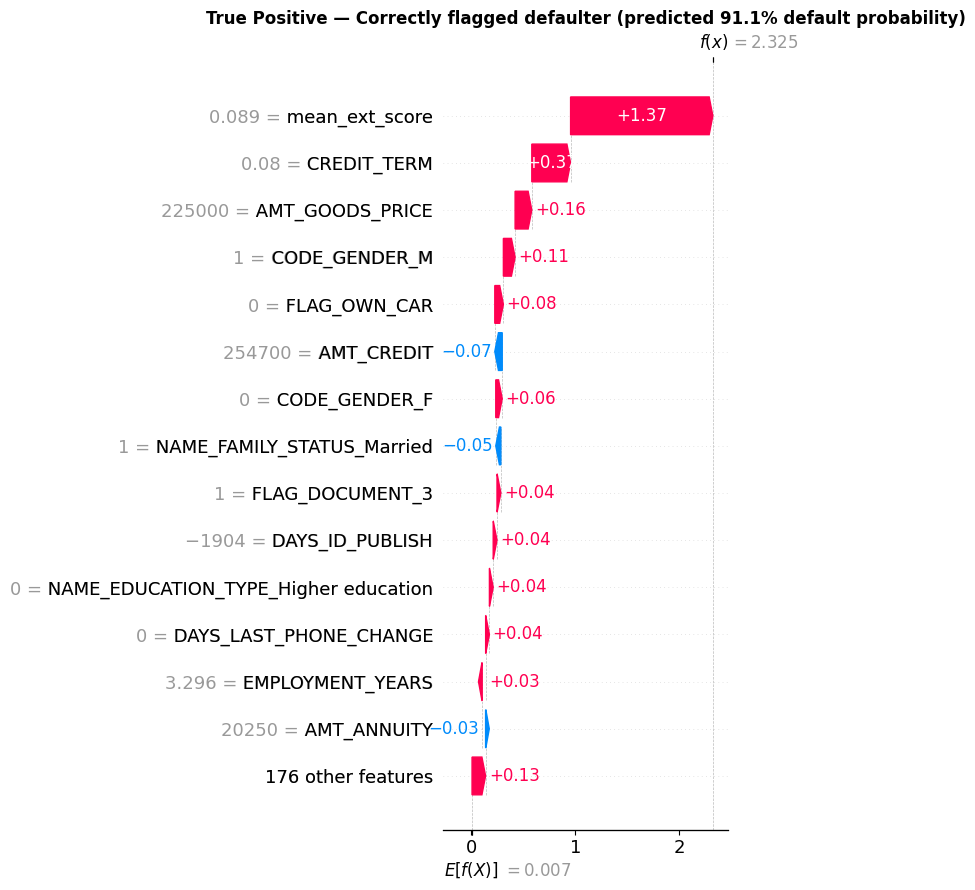

✅ True positive waterfall saved


In [11]:
# Find someone model predicted high risk AND actually defaulted
sample_probs  = model.predict_proba(X_sample)[:, 1]
actual_labels = y_test.values[y_test.index.isin(X_sample.index)]

# Reset index for alignment
X_sample_reset  = X_sample.reset_index(drop=True)
y_sample_reset  = pd.Series(
    y_test[y_test.index.isin(X_sample.index)].values
)

# Find true positives — predicted high risk AND actually defaulted
true_positive_mask = (sample_probs >= 0.5) & (y_sample_reset == 1)
true_positive_idx  = np.where(true_positive_mask)[0]

print(f"True positives in sample : {true_positive_mask.sum():,}")

# Pick the highest probability true positive
best_tp_idx  = true_positive_idx[np.argmax(sample_probs[true_positive_idx])]
best_tp_prob = sample_probs[best_tp_idx]

print(f"\nBest true positive:")
print(f"  Index              : {best_tp_idx}")
print(f"  Default probability: {best_tp_prob:.4f} ({best_tp_prob:.1%})")
print(f"  Actual label       : {'Defaulted ✅' if y_sample_reset.iloc[best_tp_idx] == 1 else 'Repaid'}")

# Waterfall plot for this true positive
shap_explanation_tp = shap.Explanation(
    values        = shap_values[best_tp_idx],
    base_values   = explainer.expected_value,
    data          = X_sample_reset.iloc[best_tp_idx],
    feature_names = X_sample.columns.tolist()
)

plt.figure(figsize=(12, 8))
shap.plots.waterfall(shap_explanation_tp, max_display=15, show=False)
plt.title(
    f'True Positive — Correctly flagged defaulter '
    f'(predicted {best_tp_prob:.1%} default probability)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../data/shap_true_positive.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ True positive waterfall saved")